In [1]:
import os
print(os.getcwd())
import sys
# sys.path.append('/media/chronos/Storage/natalie/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL')
sys.path.append(r'C:\Users\inbar\OneDrive\שולחן העבודה\DL image processing')

C:\Users\inbar\OneDrive\שולחן העבודה\DL image processing\main


In [2]:
input_file = 'list.txt'     # Change this to your input filename
output_file = 'fsm_t1_images.txt'       # New filtered list

with open(input_file, 'r') as f:
    lines = f.readlines()

# Filter lines containing 'fsm_t1'
filtered_lines = [line for line in lines if 'fsm_t1' in line]

# Save filtered lines to output file
with open(output_file, 'w') as f:
    f.writelines(filtered_lines)

print(f"Saved {len(filtered_lines)} lines to {output_file}")


Saved 38 lines to fsm_t1_images.txt


In [3]:
import numpy as np

# data = /home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/converted_npz/fsm_t1_50ww.npz")
data = np.load(r"C:\Users\inbar\DLImageProcessing\converted_npz\fsm_t1_50ww.npz")
# List all arrays stored in the .npz file
print(data.files)

# For each array (assuming 'image' is a key, or use the actual key shown in your file)
arr = data["vol"]  # or replace "image" with the actual key
print("Shape:", arr.shape)
print("Number of elements:", arr.size)
print("Data type:", arr.dtype)

['vol', 'seg']
Shape: (256, 256, 256)
Number of elements: 16777216
Data type: float32


#### **training**

split data to train and test

In [4]:
from pathlib import Path
from sklearn.model_selection import train_test_split

data_dir = Path("C:/Users/inbar/DLImageProcessing/converted_npz")

fsm_files = sorted([f for f in data_dir.glob("*.npz") if f.stem.startswith("fsm_t1")])

train_files, test_files = train_test_split(
    fsm_files,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f" Number of files {len(fsm_files)}")
print(f"Train: {len(train_files)}, Test: {len(test_files)}")
print(fsm_files)

 Number of files 10
Train: 8, Test: 2
[WindowsPath('C:/Users/inbar/DLImageProcessing/converted_npz/fsm_t1_02cd.npz'), WindowsPath('C:/Users/inbar/DLImageProcessing/converted_npz/fsm_t1_21em.npz'), WindowsPath('C:/Users/inbar/DLImageProcessing/converted_npz/fsm_t1_24dz.npz'), WindowsPath('C:/Users/inbar/DLImageProcessing/converted_npz/fsm_t1_42wk.npz'), WindowsPath('C:/Users/inbar/DLImageProcessing/converted_npz/fsm_t1_50ww.npz'), WindowsPath('C:/Users/inbar/DLImageProcessing/converted_npz/fsm_t1_54jc.npz'), WindowsPath('C:/Users/inbar/DLImageProcessing/converted_npz/fsm_t1_70qy.npz'), WindowsPath('C:/Users/inbar/DLImageProcessing/converted_npz/fsm_t1_85fp.npz'), WindowsPath('C:/Users/inbar/DLImageProcessing/converted_npz/fsm_t1_90ao.npz'), WindowsPath('C:/Users/inbar/DLImageProcessing/converted_npz/fsm_t1_96ry.npz')]


create file with all fsm paths

In [5]:
# input_file = 'list.txt'     # Change this to your input filename
# output_file = 'fsm_all_images.txt'       # New filtered list
#
# # Save filtered lines to output file
# with open(output_file, 'w') as f:
#     f.writelines(str(path) + "\n" for path in fsm_files)
#
# print(f"Saved {len(fsm_files)} lines to {output_file}")

In [6]:
#import os

#print(os.getcwd())

## %run -i voxelmorph_ extension_DL/scripts/train.py --img-list 'fsmt1_short.txt'  --epochs 1
# %run -i ../scripts/train.py --img-list fsmt1_short.txt --epochs 1

show training results

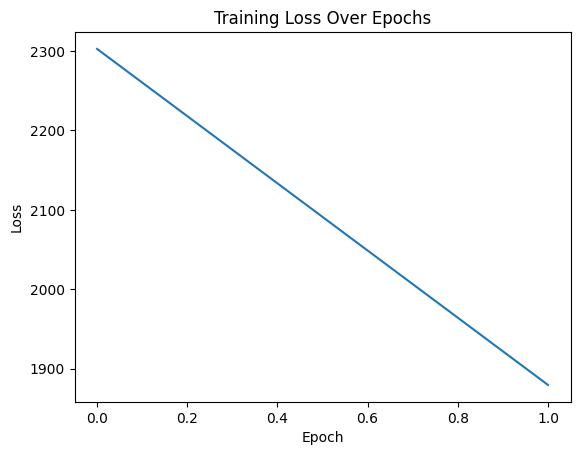

In [7]:
import matplotlib.pyplot as plt

losses = []
with open('models/loss_history.txt', 'r') as f:
    for line in f:
        losses.append(float(line.strip()))

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.show()

#### **registration**

find image pairs for registration

In [8]:
## all pairs

# from pathlib import Path
#
# data_dir = Path(r"C:/Users/inbar/DLImageProcessing/converted_npz")
# files = sorted(data_dir.glob("*.npz"))
#
# def parse_filename(filename):
#     parts = filename.stem.split('_')
#     if len(parts) < 3:
#         return None, None
#     exam_type = parts[1]
#     patient = parts[2]
#     return exam_type, patient
#
# pairs = []
# for i, file_i in enumerate(files):
#     exam_i, patient_i = parse_filename(file_i)
#     if exam_i is None:
#         continue
#     for j, file_j in enumerate(files):
#         if i >= j:
#             continue
#         exam_j, patient_j = parse_filename(file_j)
#         if exam_j is None:
#             continue
#
#         if (patient_i == patient_j and exam_i != exam_j) or (exam_i == exam_j and patient_i != patient_j):
#             pairs.append((file_i, file_j))
#
# print(f"Found {len(pairs)} pairs.")


In [9]:
## only fsm t1 pairs, for now using all the fsm t1 data but after only data dest from early

from pathlib import Path
from itertools import product

data_dir = Path("C:/Users/inbar/DLImageProcessing/converted_npz")

fsm_files = sorted([f for f in data_dir.glob("*.npz") if f.stem.startswith("fsm_t1")])

pairs = [(moving, fixed) for moving, fixed in product(fsm_files, fsm_files) if moving != fixed]

print(f"Found {len(fsm_files)} fsm files")
print(f"Found {len(pairs)} pairs.")

Found 10 fsm files
Found 90 pairs.


run registration

In [10]:
output_dir = data_dir / "warped_results"
output_dir.mkdir(exist_ok=True)
results = []

for j, (moving_file, fixed_file) in enumerate(pairs, start=1):
    moving_name = moving_file.stem
    fixed_name = fixed_file.stem
    output_file = output_dir / f"warped_{moving_name}_{fixed_name}.npz"

    %run -i ../scripts/register.py --moving {fixed_file} --fixed {moving_file} --moved {output_file} --model ../models/0002.pt --gpu 0

    print(f"saved: {output_file}")
    results.append((moving_file, fixed_file, output_file))
    if j == 7:  # just for now, doesn't want long run
        break


Bottleneck features saved to ..\data\outputs\bottleneck_features_20250810_204234.npy, with shape (1, 22, 8, 8, 8)
saved: C:\Users\inbar\DLImageProcessing\converted_npz\warped_results\warped_fsm_t1_02cd_fsm_t1_21em.npz
Bottleneck features saved to ..\data\outputs\bottleneck_features_20250810_204237.npy, with shape (1, 22, 8, 8, 8)
saved: C:\Users\inbar\DLImageProcessing\converted_npz\warped_results\warped_fsm_t1_02cd_fsm_t1_24dz.npz
Bottleneck features saved to ..\data\outputs\bottleneck_features_20250810_204240.npy, with shape (1, 22, 8, 8, 8)
saved: C:\Users\inbar\DLImageProcessing\converted_npz\warped_results\warped_fsm_t1_02cd_fsm_t1_42wk.npz
Bottleneck features saved to ..\data\outputs\bottleneck_features_20250810_204244.npy, with shape (1, 22, 8, 8, 8)
saved: C:\Users\inbar\DLImageProcessing\converted_npz\warped_results\warped_fsm_t1_02cd_fsm_t1_50ww.npz
Bottleneck features saved to ..\data\outputs\bottleneck_features_20250810_204249.npy, with shape (1, 22, 8, 8, 8)
saved: C:\User

PCA

In [ ]:
import numpy as np
from sklearn.decomposition import PCA

# נניח שיש לך רשימה של שמות קבצים
files = [
    "../../data/output/bottleneck_features_1.npy",
    "../../data/output/bottleneck_features_2.npy",
    "../../data/output/bottleneck_features_3.npy",
    # ...
]

# טען את כל הדאטה למערך numpy אחד
all_features = []
for f in files:
    data = np.load(f)  # shape: (1, 22, 8, 8, 8)
    all_features.append(data[0])  # shape: (22, 8, 8, 8)

all_features = np.stack(all_features, axis=0)  # shape: (N, 22, 8, 8, 8)

# עכשיו נעשה reshape
N = all_features.shape[0]
channels = all_features.shape[1]
spatial_size = all_features.shape[2] * all_features.shape[3] * all_features.shape[4]

# נרצה דוגמאות בשורות ותכונות בעמודות
# אפשר לעשות: כל voxel ב-8x8x8 לכל דוגמה זה sample נפרד (אם זה הגיוני)
features_reshaped = all_features.transpose(0, 2, 3, 4, 1).reshape(-1, channels)  # (N*512, 22)

print("Shape for PCA:", features_reshaped.shape)

# אפשר לנרמל לפני PCA אם רוצים
features_reshaped -= features_reshaped.mean(axis=0)
features_reshaped /= features_reshaped.std(axis=0) + 1e-10

# PCA
pca = PCA(n_components=5)
pca_result = pca.fit_transform(features_reshaped)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Shape after reshaping: (1408, 8)
Explained variance ratio: [9.8543322e-01 1.0412544e-02 3.6154478e-03 4.3555739e-04 8.9825910e-05]


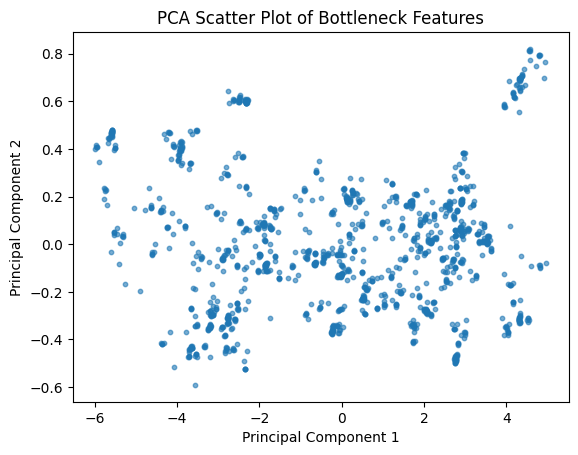

In [13]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# טען את הפיצ'רים
features = np.load("../../data/output/bottleneck_features.npy")  # צורה: (8,8,8,22,1)

# אם יש מימד אחרון של 1, נסיר אותו
if features.shape[-1] == 1:
    features = features[..., 0]  # עכשיו (8,8,8,22)

# נעביר את ערוץ הפיצ'רים למימד ראשון
# נכון: (8,8,8,22) -> (22, 8,8,8)
features = np.moveaxis(features, -1, 0)

# עכשיו נעצב ל- (samples, features)
features_reshaped = features.reshape(features.shape[0], -1).T  # (512, 22)

print("Shape after reshaping:", features_reshaped.shape)  # (512, 22)

# נרמול - mean=0, std=1 על כל feature (כל עמודה)
scaler = StandardScaler()
features_normalized = scaler.fit_transform(features_reshaped)

# PCA
pca = PCA(n_components=5)
pca_result = pca.fit_transform(features_normalized)  # (512, 5)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# scatter plot של כל נקודות ה-512 לפי הרכיב הראשון והשני
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=10, alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot of Bottleneck Features")
plt.show()


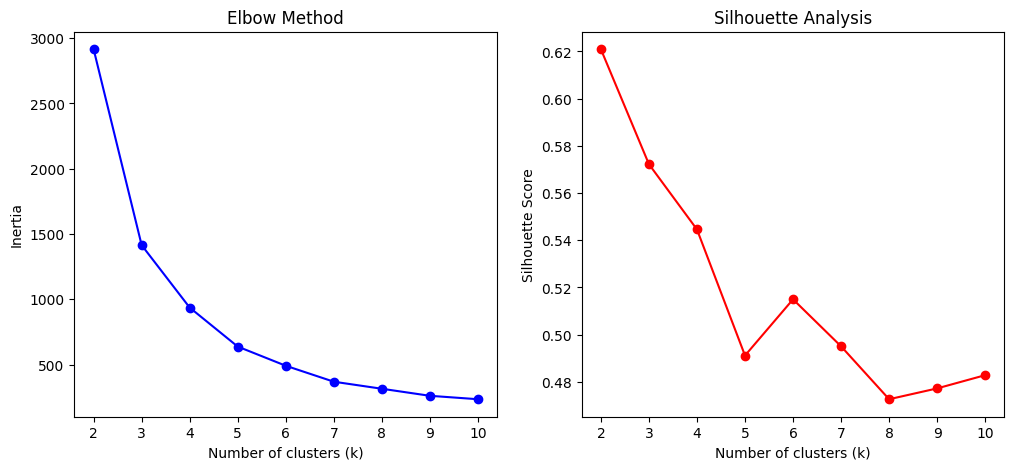

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette = []
K = range(2, 11)  # בודקים מ-2 עד 10 אשכולות

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_result)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(pca_result, labels))

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K, silhouette, 'ro-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

plt.show()


DBSCAN found 2 clusters


C:\Users\inbar\AppData\Local\Temp\ipykernel_8684\356873545.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


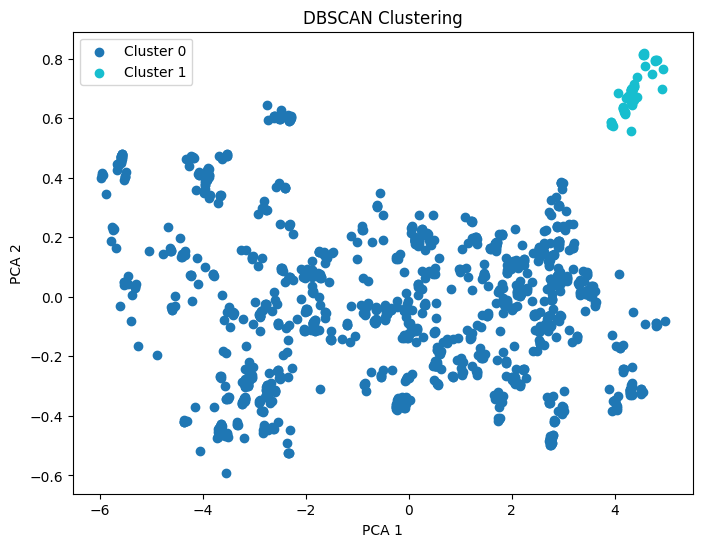

In [18]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# נניח pca_result הוא (512, 5)
# נעבוד על שני הקומפוננטים הראשונים להצגה

dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(pca_result[:, :2])

print(f"DBSCAN found {len(set(clusters)) - (1 if -1 in clusters else 0)} clusters")

plt.figure(figsize=(8,6))
unique_labels = set(clusters)
colors = plt.cm.get_cmap('tab10', len(unique_labels))

for k in unique_labels:
    class_mask = (clusters == k)
    xy = pca_result[class_mask, :2]
    if k == -1:
        plt.scatter(xy[:, 0], xy[:, 1], c='k', marker='x', label='Noise')
    else:
        plt.scatter(xy[:, 0], xy[:, 1], color=colors(k), label=f'Cluster {k}')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('DBSCAN Clustering')
plt.legend()
plt.show()


In [ ]:
# %run -i voxelmorph_extension_DL/scripts/register.py --moving converted_npz/fsm_pd_54jc.npz --fixed converted_npz/fsm_pd_30gy.npz --moved warped_integrated.npz --model models/0002.pt --gpu 0
# %run -i ../scripts/register.py --moving "C:/Users/inbar/DLImageProcessing/converted_npz/fsm_pd_54jc.npz" --fixed "C:/Users/inbar/DLImageProcessing/converted_npz/fsm_pd_93cs.npz" --moved "C:/Users/inbar/DLImageProcessing/warped_integrated_npz/warped_integrated.npz" --model ../models/0002.pt --gpu 0



find shape to every image

In [11]:
import numpy as np
from pathlib import Path

data_dir = Path(r"C:\Users\inbar\DLImageProcessing\converted_npz")

for file in data_dir.glob("*.npz"):
    try:
        arr = np.load(file)["vol"]
        print(f"{file.name}: shape={arr.shape}")
    except Exception as e:
        print(f"{file.name}: error loading -> {e}")

asl_epi_105.npz: shape=(64, 64, 22)
asl_epi_106.npz: shape=(64, 64, 22)
asl_epi_112.npz: shape=(64, 64, 22)
asl_epi_113.npz: shape=(64, 64, 22)
asl_epi_119.npz: shape=(64, 64, 22)
asl_epi_120.npz: shape=(64, 64, 22)
asl_epi_122.npz: shape=(64, 64, 22)
asl_epi_124.npz: shape=(64, 64, 22)
asl_epi_125.npz: shape=(64, 64, 22)
asl_epi_127.npz: shape=(64, 64, 22)
asl_epi_134.npz: shape=(64, 64, 22)
asl_epi_135.npz: shape=(64, 64, 22)
asl_epi_138.npz: shape=(64, 64, 22)
asl_epi_140.npz: shape=(64, 64, 22)
asl_epi_142.npz: shape=(64, 64, 22)
asl_epi_145.npz: shape=(64, 64, 22)
asl_epi_146.npz: shape=(64, 64, 22)
asl_epi_150.npz: shape=(64, 64, 22)
asl_epi_152.npz: shape=(64, 64, 22)
asl_t1_105.npz: shape=(256, 256, 256)
asl_t1_111.npz: shape=(256, 256, 256)
asl_t1_116.npz: shape=(256, 256, 256)
asl_t1_119.npz: shape=(256, 256, 256)
asl_t1_127.npz: shape=(256, 256, 256)
asl_t1_134.npz: shape=(256, 256, 256)
asl_t1_149.npz: shape=(256, 256, 256)
fsm_pd_10cv.npz: shape=(256, 256, 256)
fsm_pd_54jc

In [31]:
# %run -i ../scripts/register.py --moving "C:/Users/inbar/DLImageProcessing/converted_npz/fsm_pd_54jc.npz" --fixed "C:/Users/inbar/DLImageProcessing/converted_npz/fsm_pd_93cs.npz" --moved "C:/Users/inbar/DLImageProcessing/warped_integrated_npz/warped_integrated.npz" --model ../models/0002.pt --gpu 0

show results

In [14]:
import matplotlib.pyplot as plt

# Helper functions.
def normalize(x):
  x -= x.min()
  return x / x.max()


def show(im, title=None):
    im = np.asarray(im).reshape((256, 256, 256))
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    slices = im[:, 125, :], im[:, :, 127], im[127, :, :].T
    for im_slice, ax in zip(slices, axes):
        ax.imshow(im_slice, cmap='gray')
        ax.set_axis_off()

    if title:
        axes[1].text(0.50, 1.05, title, ha='center', transform=axes[1].transAxes, size=14)


def load_volume(path):
    nii_img = np.load(path)
    nii_img = nii_img["vol"]
    return nii_img

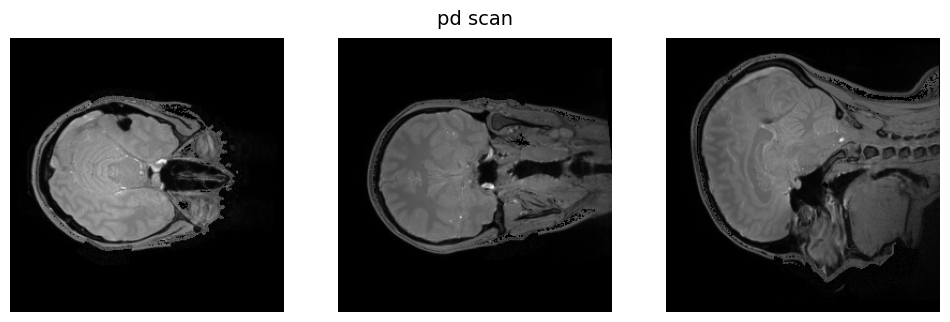

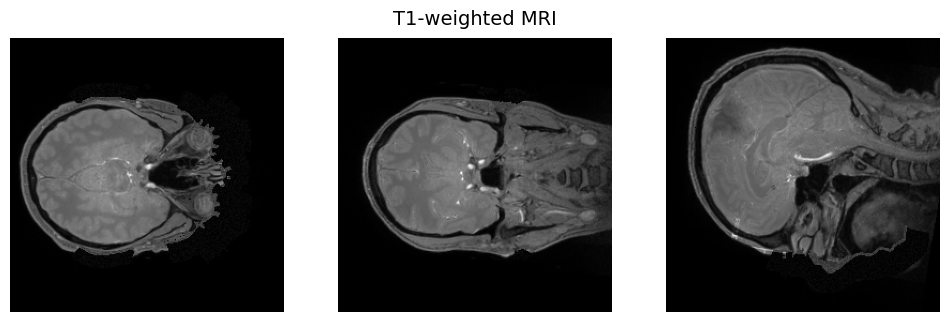

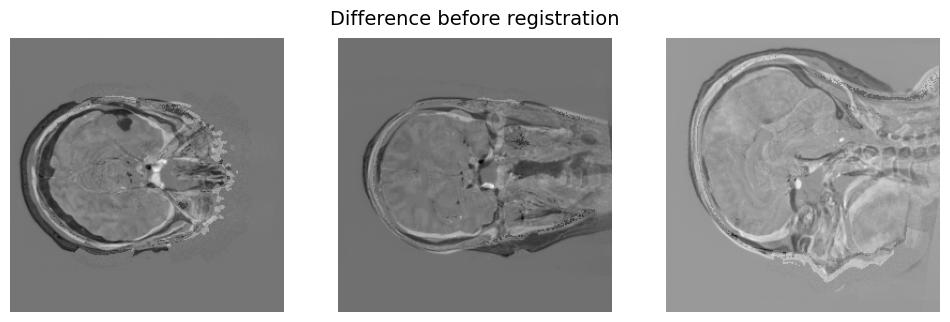

In [16]:
# pd = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/converted_npz/fsm_pd_30gy.npz')
# t1 = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/converted_npz/fsm_pd_54jc.npz')
pd = load_volume('C:/Users/inbar/DLImageProcessing/converted_npz/fsm_pd_54jc.npz')
t1 = load_volume('C:/Users/inbar/DLImageProcessing/converted_npz/fsm_pd_93cs.npz')

before = normalize(pd) - normalize(t1)

show(pd, title='pd scan')
show(t1, title='T1-weighted MRI')
show(before, title='Difference before registration')

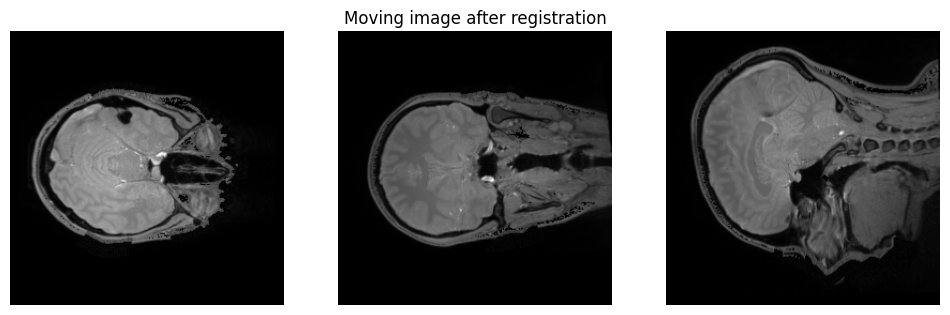

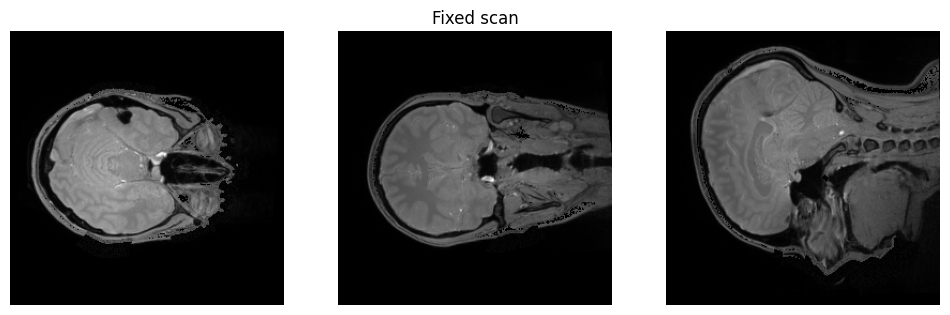

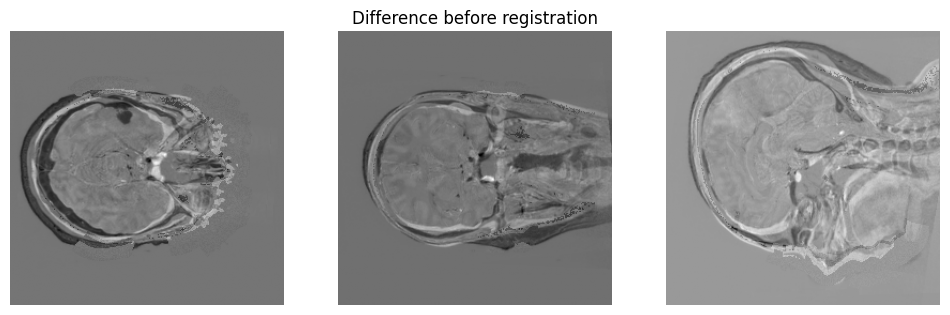

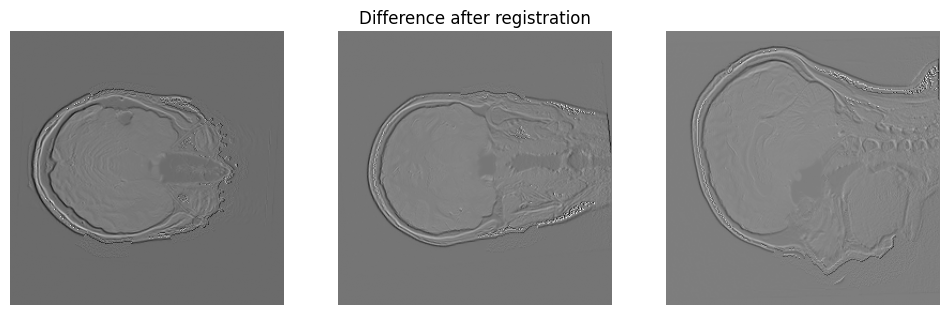

In [33]:
# pd = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/warped_integrated.npz')
# t1 = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/converted_npz/fsm_pd_30gy.npz')
warped = load_volume('C:/Users/inbar/DLImageProcessing/warped_integrated_npz/warped_integrated.npz')
warped_fixed_axes = warped.transpose(2, 1, 0)

before = normalize(pd) - normalize(t1)

after = normalize(warped_fixed_axes) - normalize(pd)

show(warped_fixed_axes, title='Moving image after registration')
show(pd, title='Fixed scan')
show(before, title='Difference before registration')
show(after, title='Difference after registration')



#### **inference**

In [37]:
def mse(fixed, moving, warped):
    warped_fixed_axes = warped.transpose(2, 1, 0)
    error = np.mean((normalize(fixed) - normalize(moving))**2)
    error_after_reg = np.mean((normalize(fixed) - normalize(warped_fixed_axes))**2)
    return error, error_after_reg

# def dice_score(seg_fixed, seg_warped):
#     intersection = np.sum((seg_fixed > 0) & (seg_warped > 0))
#     size_sum = np.sum(seg_fixed > 0) + np.sum(seg_warped > 0)
#     return 2 * intersection / size_sum if size_sum > 0 else 1.0

MSE = []
MSE_after_reg = []
for moving_file, fixed_file, warped_file in results:
    fixed = load_volume(fixed_file)
    warped = load_volume(warped_file)
    moving = load_volume(moving_file)

    # MSE
    error, error_after_reg = mse(fixed, moving, warped)

    MSE.append(error)
    MSE_after_reg.append(error_after_reg)

    # Dice - for segmentation

    # seg_fixed = load_segmentation(...)
    # seg_warped = load_segmentation(...)
    # dice = dice_score(seg_fixed, seg_warped)


    # dice_score = dice_score(fixed, warped)

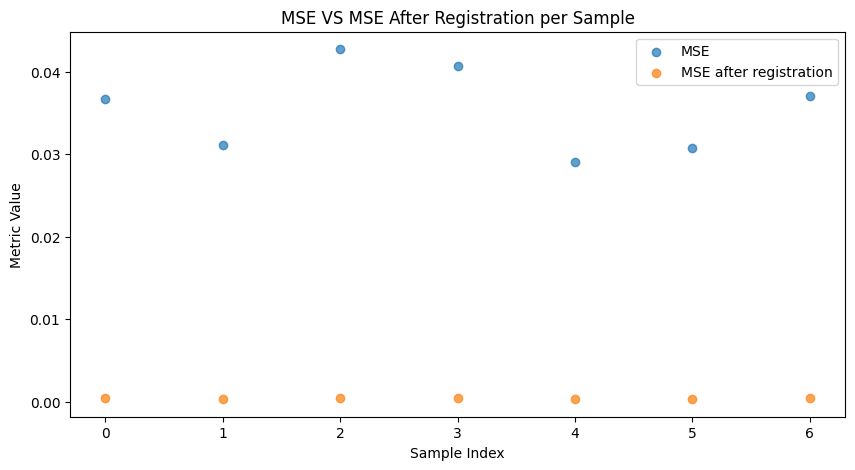

In [39]:
import matplotlib.pyplot as plt

indices = list(range(len(MSE)))

plt.figure(figsize=(10,5))
plt.scatter(indices, MSE, label='MSE', alpha=0.7)
plt.scatter(indices, MSE_after_reg, label='MSE after registration', alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('Metric Value')
plt.title('MSE VS MSE After Registration per Sample')
plt.legend()
plt.show()

In [ ]:
%./scripts/tf/test.py --model model.h5 --atlas atlas.npz --scans scan01.npz scan02.npz scan03.npz --labels labels.npz